
# CPU-only Conv2D Batch Performance — 20 Images

This notebook matches the style and output format of the FPGA-only batch notebook, but it runs the same 5×5 Conv2D algorithms on the CPU.

It is designed to work on both:

- a normal laptop/PC CPU
- the PYNQ-Z2 ARM CPU

Expected folder structure:

```text
project_folder/
├── cpu_conv2d_performance_batch_20_assignment.ipynb
└── input/
    ├── 01.jpg / 01.png / 01
    ├── 02.jpg / 02.png / 02
    ├── ...
    └── 20.jpg / 20.png / 20
```

The notebook does not resize the images. It checks that every input image is already `640 × 640`.

The notebook has separate execution cells for:

1. Blur 5×5 batch results
2. Edge-emphasis 5×5 batch results
3. Final combined statistics and project-level summary


In [ ]:

from __future__ import annotations

import csv
import os
import platform
import sys
import time
import traceback
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple, Any

import numpy as np
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Image as IPythonImage
    IPYTHON_DISPLAY_AVAILABLE = True
except Exception:
    IPYTHON_DISPLAY_AVAILABLE = False

try:
    from PIL import Image
    PIL_AVAILABLE = True
except Exception:
    PIL_AVAILABLE = False

try:
    import psutil
    PSUTIL_AVAILABLE = True
except Exception:
    psutil = None
    PSUTIL_AVAILABLE = False


# Configuration
# ------------------------------------------------------

OUTPUT_DIR = "cpu_only_outputs"
INPUT_DIR_NAME = "input"

EXPECTED_IMAGE_SIZE = (640, 640)       # width, height
EXPECTED_IMAGE_COUNT = 20
INPUT_IMAGE_STEMS = [f"{i:02d}" for i in range(1, EXPECTED_IMAGE_COUNT + 1)]
INPUT_EXTENSIONS = ["", ".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

# Batch mode: one measured CPU pass per image.
# This is the same processing structure as the FPGA notebook, but executed on CPU.
SAVE_IMAGES = True
SAVE_FIRST_N_OUTPUT_IMAGES = 20        # keep 20 for full evidence; lower it if storage is tight

MAX_HEIGHT = 1080
MAX_WIDTH = 1920


MANUAL_POWER_WATTS = None              

print("Environment")
print("-----------")
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("CPU execution mode: available")
print("psutil available:", PSUTIL_AVAILABLE)

print("\nConfiguration")
print("-------------")
print("Input folder:", INPUT_DIR_NAME)
print("Expected image size:", EXPECTED_IMAGE_SIZE)
print("Expected image count:", EXPECTED_IMAGE_COUNT)
print("Manual power watts:", MANUAL_POWER_WATTS)


Environment
-----------
Python: 3.13.7
Platform: Windows-11-10.0.26200-SP0
CPU execution mode: available
psutil available: True

Configuration
-------------
Input folder: input
Expected image size: (640, 640)
Expected image count: 20
Manual power watts: None


In [ ]:


# Utility helpers and system sensors
# -----------------------------------------------

def notebook_folder() -> Path:
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd().resolve()


def format_duration(seconds: float) -> str:
    total = int(round(max(0.0, seconds)))
    h = total // 3600
    m = (total % 3600) // 60
    s = total % 60
    if h:
        return f"{h}h {m:02d}m {s:02d}s"
    if m:
        return f"{m}m {s:02d}s"
    return f"{s}s"


def summarize_values(values: Sequence[float]) -> Dict[str, float]:
    arr = np.asarray(values, dtype=np.float64)
    if arr.size == 0:
        return {
            "mean": float("nan"),
            "median": float("nan"),
            "std": float("nan"),
            "min": float("nan"),
            "max": float("nan"),
            "sum": float("nan"),
        }
    return {
        "mean": float(np.mean(arr)),
        "median": float(np.median(arr)),
        "std": float(np.std(arr)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
        "sum": float(np.sum(arr)),
    }


def save_uint8_image(path: Path, arr: np.ndarray) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    if PIL_AVAILABLE:
        Image.fromarray(arr.astype(np.uint8), mode="L").save(path)
    else:
        plt.imsave(path, arr.astype(np.uint8), cmap="gray", vmin=0, vmax=255)


def _read_proc_meminfo() -> Dict[str, float]:
    values: Dict[str, float] = {}
    try:
        with open("/proc/meminfo", "r", encoding="utf-8") as f:
            for line in f:
                parts = line.split()
                if len(parts) >= 2:
                    values[parts[0].rstrip(":")] = float(parts[1]) * 1024.0
    except Exception:
        pass
    return values


def read_temperatures_c() -> Dict[str, float]:
    temps: Dict[str, float] = {}

    # Common Linux thermal zones.
    for p in Path("/sys/class/thermal").glob("thermal_zone*/temp"):
        try:
            zone = p.parent.name
            type_path = p.parent / "type"
            label = type_path.read_text(errors="ignore").strip() if type_path.exists() else zone
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    # hwmon temperature inputs.
    for p in Path("/sys/class/hwmon").glob("hwmon*/temp*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            temp_c = raw / 1000.0 if raw > 1000 else raw
            temps[label] = temp_c
        except Exception:
            pass

    # psutil sensors, when available.
    if PSUTIL_AVAILABLE:
        try:
            sensor_map = psutil.sensors_temperatures(fahrenheit=False)
            for group, entries in sensor_map.items():
                for idx, entry in enumerate(entries):
                    name = entry.label or f"{group}_{idx}"
                    if entry.current is not None:
                        temps[name] = float(entry.current)
        except Exception:
            pass

    return temps


def read_power_watts() -> Dict[str, float]:

    powers: Dict[str, float] = {}

    # Linux hwmon power inputs.
    for p in Path("/sys/class/hwmon").glob("hwmon*/power*_input"):
        try:
            label = p.parent.name + "_" + p.stem
            raw = float(p.read_text().strip())
            if raw > 100000:
                watts = raw / 1_000_000.0
            elif raw > 1000:
                watts = raw / 1000.0
            else:
                watts = raw
            powers[label] = watts
        except Exception:
            pass

    # Some IIO power monitors expose voltage/current only.
    for dev in Path("/sys/bus/iio/devices").glob("iio:device*"):
        try:
            name_path = dev / "name"
            dev_name = name_path.read_text(errors="ignore").strip() if name_path.exists() else dev.name
            voltage_files = list(dev.glob("in_voltage*_input"))
            current_files = list(dev.glob("in_current*_input"))
            for vf in voltage_files:
                suffix = vf.name.replace("in_voltage", "").replace("_input", "")
                cf = dev / f"in_current{suffix}_input"
                if not cf.exists() and current_files:
                    cf = current_files[0]
                if cf.exists():
                    v_raw = float(vf.read_text().strip())
                    c_raw = float(cf.read_text().strip())

                    # Common convention: voltage in mV and current in mA.
                    volts = v_raw / 1000.0 if v_raw > 100 else v_raw
                    amps = c_raw / 1000.0 if c_raw > 10 else c_raw
                    powers[f"{dev_name}_ch{suffix}"] = volts * amps
        except Exception:
            pass

    if not powers and MANUAL_POWER_WATTS is not None:
        powers["manual_power_watts"] = float(MANUAL_POWER_WATTS)

    return powers


def system_snapshot(label: str) -> Dict[str, Any]:
    snap: Dict[str, Any] = {
        "label": label,
        "timestamp_s": time.time(),
        "cpu_percent": float("nan"),
        "ram_used_mb": float("nan"),
        "ram_total_mb": float("nan"),
        "ram_percent": float("nan"),
        "process_rss_mb": float("nan"),
        "loadavg_1min": float("nan"),
        "temperatures_c": read_temperatures_c(),
        "power_watts": read_power_watts(),
    }

    if PSUTIL_AVAILABLE:
        try:
            snap["cpu_percent"] = float(psutil.cpu_percent(interval=0.1))
            vm = psutil.virtual_memory()
            snap["ram_used_mb"] = float(vm.used) / (1024.0 * 1024.0)
            snap["ram_total_mb"] = float(vm.total) / (1024.0 * 1024.0)
            snap["ram_percent"] = float(vm.percent)
            snap["process_rss_mb"] = float(psutil.Process(os.getpid()).memory_info().rss) / (1024.0 * 1024.0)
        except Exception:
            pass
    else:
        meminfo = _read_proc_meminfo()
        if "MemTotal" in meminfo and "MemAvailable" in meminfo:
            total = meminfo["MemTotal"]
            used = total - meminfo["MemAvailable"]
            snap["ram_total_mb"] = total / (1024.0 * 1024.0)
            snap["ram_used_mb"] = used / (1024.0 * 1024.0)
            snap["ram_percent"] = 100.0 * used / total if total > 0 else float("nan")
        try:
            with open("/proc/self/statm", "r", encoding="utf-8") as f:
                pages = int(f.read().split()[1])
                snap["process_rss_mb"] = pages * os.sysconf("SC_PAGE_SIZE") / (1024.0 * 1024.0)
        except Exception:
            pass

    try:
        snap["loadavg_1min"] = float(os.getloadavg()[0])
    except Exception:
        pass

    return snap


def primary_temperature(snapshot: Dict[str, Any]) -> float:
    temps = snapshot.get("temperatures_c", {})
    if not temps:
        return float("nan")
    # Return highest observed CPU/SoC temperature as a conservative single value.
    return float(max(temps.values()))


def total_power_watts(snapshot: Dict[str, Any]) -> float:
    powers = snapshot.get("power_watts", {})
    if not powers:
        return float("nan")
    return float(sum(powers.values()))


def energy_joules(power_watts: float, seconds: float) -> float:
    if not np.isfinite(power_watts):
        return float("nan")
    return float(power_watts * seconds)


def print_system_snapshot(snap: Dict[str, Any]) -> None:
    temp = primary_temperature(snap)
    power = total_power_watts(snap)

    print(
        f"{snap['label']}: "
        f"CPU={snap['cpu_percent']:.1f}% | "
        f"RAM={snap['ram_used_mb']:.1f}/{snap['ram_total_mb']:.1f} MB "
        f"({snap['ram_percent']:.1f}%) | "
        f"Process={snap['process_rss_mb']:.1f} MB | "
        f"Load1={snap['loadavg_1min']:.2f} | "
        f"Temp={temp:.1f} C | "
        f"Power={power:.3f} W"
    )

    if not snap.get("power_watts"):
        print("  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.")


In [ ]:

# Kernels and image loading
# ------------------------------------------------

KERNELS: Dict[str, Dict[str, object]] = {
    "blur5x5": {
        "display": "Blur 5x5",
        "kernel": np.ones((5, 5), dtype=np.int16),
        "divisor": 25,
        "bias": 0,
    },
    "edge_emphasis5x5": {
        "display": "Edge emphasis 5x5",
        "kernel": np.array(
            [
                [-1, -1, -1, -1, -1],
                [-1, 1, 1, 1, -1],
                [-1, 1, 16, 1, -1],
                [-1, 1, 1, 1, -1],
                [-1, -1, -1, -1, -1],
            ],
            dtype=np.int16,
        ),
        "divisor": 1,
        "bias": 0,
    },
}


def find_image_by_stem(input_dir: Path, stem: str) -> Path:
    for ext in INPUT_EXTENSIONS:
        p = input_dir / f"{stem}{ext}"
        if p.exists() and p.is_file():
            return p
    raise FileNotFoundError(
        f"Missing image '{stem}' in {input_dir}. "
        f"Checked extensions: {INPUT_EXTENSIONS}"
    )


def load_input_batch(folder: Path) -> List[Tuple[str, Path, np.ndarray]]:
    if not PIL_AVAILABLE:
        raise RuntimeError("Pillow/PIL is required to load the input image folder.")

    input_dir = folder / INPUT_DIR_NAME
    if not input_dir.exists():
        raise FileNotFoundError(f"Input folder not found: {input_dir}")

    expected_w, expected_h = EXPECTED_IMAGE_SIZE
    loaded: List[Tuple[str, Path, np.ndarray]] = []

    for stem in INPUT_IMAGE_STEMS:
        path = find_image_by_stem(input_dir, stem)
        img_pil = Image.open(path).convert("L")
        width, height = img_pil.size

        if (width, height) != (expected_w, expected_h):
            raise ValueError(
                f"Image {path.name} has size {width}x{height}, "
                f"but expected {expected_w}x{expected_h}. "
                "This notebook does not resize batch images."
            )

        arr = np.asarray(img_pil, dtype=np.uint8)
        loaded.append((stem, path, arr))

    print(f"Loaded {len(loaded)} images from {input_dir}")
    print("First image:", loaded[0][1].name, loaded[0][2].shape, loaded[0][2].dtype)
    print("Last image:", loaded[-1][1].name, loaded[-1][2].shape, loaded[-1][2].dtype)

    return loaded


In [ ]:

# CPU Conv2D implementation
# ------------------------------------------------

def trunc_div_toward_zero(a: int, b: int) -> int:
    if b == 0:
        return int(a)
    return int(a / b)


def clip_u8(value: int) -> np.uint8:
    if value < 0:
        return np.uint8(0)
    if value > 255:
        return np.uint8(255)
    return np.uint8(value)


def conv2d_cpu_reference_exact(
    img: np.ndarray,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> np.ndarray:
    """
    Exact CPU version of the same 5x5 Conv2D operation.

    It follows the same arithmetic convention as the HLS accelerator:
    - uint8 grayscale input
    - uint8 grayscale output
    - 5x5 signed integer kernel
    - 2-pixel border copied unchanged
    - C/C++ style integer division, truncating toward zero
    - clipping to 0..255
    """
    rows, cols = img.shape
    out = img.copy()

    if rows < 5 or cols < 5:
        return out

    for r in range(2, rows - 2):
        for c in range(2, cols - 2):
            acc = 0
            for kr in range(5):
                rr = r + kr - 2
                for kc in range(5):
                    cc = c + kc - 2
                    acc += int(img[rr, cc]) * int(kernel[kr, kc])

            val = trunc_div_toward_zero(acc, int(divisor)) + int(bias)
            out[r, c] = clip_u8(val)

    return out


def run_cpu_once(
    img: np.ndarray,
    kernel: np.ndarray,
    divisor: int,
    bias: int,
) -> Tuple[np.ndarray, float, float]:
    """
    Returns:
    - output image
    - CPU processing time in ms
    - CPU end-to-end time in ms

    For CPU-only mode, processing time and end-to-end time are almost the same.
    End-to-end includes the small function call/timing wrapper overhead.
    """
    t_total0 = time.perf_counter()

    t_kernel0 = time.perf_counter()
    out = conv2d_cpu_reference_exact(img, kernel, divisor, bias)
    t_kernel1 = time.perf_counter()

    t_total1 = time.perf_counter()

    return out, (t_kernel1 - t_kernel0) * 1000.0, (t_total1 - t_total0) * 1000.0


In [ ]:

# Batch execution helpers
# --------------------------------------------------

ALL_BATCH_RESULTS: Dict[str, Dict[str, Any]] = {}


def run_kernel_on_batch(kernel_key: str) -> Dict[str, Any]:
    if kernel_key not in KERNELS:
        raise ValueError(f"Unknown kernel: {kernel_key}. Available kernels: {list(KERNELS.keys())}")

    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    batch = load_input_batch(folder)

    cfg = KERNELS[kernel_key]
    kernel = cfg["kernel"]
    divisor = int(cfg["divisor"])
    bias = int(cfg["bias"])
    display_name = str(cfg["display"])

    kernel_output_dir = out_dir / kernel_key
    kernel_output_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print(f"CPU batch run: {display_name}")
    print("=" * 100)
    print("Images:", len(batch))
    print("Image size:", f"{EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}")
    print("Output folder:", kernel_output_dir)

    before = system_snapshot(f"before_{kernel_key}")
    print_system_snapshot(before)

    per_image_rows: List[Dict[str, Any]] = []
    processing_times_ms: List[float] = []
    total_times_ms: List[float] = []

    batch_wall_start = time.perf_counter()

    print("\nMeasured batch processing")
    for idx, (stem, path, img) in enumerate(batch, start=1):
        cpu_out, processing_ms, total_ms = run_cpu_once(img, kernel, divisor, bias)

        processing_times_ms.append(processing_ms)
        total_times_ms.append(total_ms)

        if SAVE_IMAGES and idx <= SAVE_FIRST_N_OUTPUT_IMAGES:
            save_uint8_image(kernel_output_dir / f"{stem}_{kernel_key}_cpu.png", cpu_out)

        out_min = int(cpu_out.min())
        out_max = int(cpu_out.max())
        out_mean = float(cpu_out.mean())

        row = {
            "image_id": stem,
            "image_file": path.name,
            "kernel_key": kernel_key,
            "kernel_display": display_name,
            "rows": int(img.shape[0]),
            "cols": int(img.shape[1]),
            "pixels": int(img.size),
            "cpu_processing_ms": float(processing_ms),
            "cpu_total_ms": float(total_ms),
            "output_min": out_min,
            "output_max": out_max,
            "output_mean": out_mean,
            "output_all_zero": bool(out_max == 0),
        }
        per_image_rows.append(row)

        print(
            f"  {idx:02d}/{len(batch)} {path.name}: "
            f"processing={processing_ms:.3f} ms, total={total_ms:.3f} ms, "
            f"out min/max/mean={out_min}/{out_max}/{out_mean:.2f}"
        )

    batch_wall_s = time.perf_counter() - batch_wall_start

    after = system_snapshot(f"after_{kernel_key}")
    print_system_snapshot(after)

    processing_stats = summarize_values(processing_times_ms)
    total_stats = summarize_values(total_times_ms)

    total_pixels = int(sum(row["pixels"] for row in per_image_rows))
    total_processing_s = processing_stats["sum"] / 1000.0
    total_end_to_end_s = total_stats["sum"] / 1000.0

    processing_mpix_s = total_pixels / total_processing_s / 1_000_000.0 if total_processing_s > 0 else float("nan")
    total_mpix_s = total_pixels / total_end_to_end_s / 1_000_000.0 if total_end_to_end_s > 0 else float("nan")

    power_before_w = total_power_watts(before)
    power_after_w = total_power_watts(after)
    avg_power_w = float(np.nanmean([power_before_w, power_after_w])) if np.isfinite(power_before_w) or np.isfinite(power_after_w) else float("nan")

    energy_processing_j = energy_joules(avg_power_w, total_processing_s)
    energy_total_j = energy_joules(avg_power_w, total_end_to_end_s)
    energy_wall_j = energy_joules(avg_power_w, batch_wall_s)

    result = {
        "processor": "CPU",
        "platform": platform.platform(),
        "kernel_key": kernel_key,
        "kernel_display": display_name,
        "image_count": len(batch),
        "image_width": EXPECTED_IMAGE_SIZE[0],
        "image_height": EXPECTED_IMAGE_SIZE[1],
        "total_pixels": total_pixels,
        "cpu_processing_total_ms": processing_stats["sum"],
        "cpu_processing_mean_ms": processing_stats["mean"],
        "cpu_processing_median_ms": processing_stats["median"],
        "cpu_processing_std_ms": processing_stats["std"],
        "cpu_processing_min_ms": processing_stats["min"],
        "cpu_processing_max_ms": processing_stats["max"],
        "cpu_end_to_end_total_ms": total_stats["sum"],
        "cpu_end_to_end_mean_ms": total_stats["mean"],
        "cpu_end_to_end_median_ms": total_stats["median"],
        "cpu_end_to_end_std_ms": total_stats["std"],
        "cpu_end_to_end_min_ms": total_stats["min"],
        "cpu_end_to_end_max_ms": total_stats["max"],
        "batch_wall_time_s": batch_wall_s,
        "cpu_processing_throughput_mpix_s": processing_mpix_s,
        "cpu_end_to_end_throughput_mpix_s": total_mpix_s,
        "cpu_load_before_percent": before["cpu_percent"],
        "cpu_load_after_percent": after["cpu_percent"],
        "ram_used_before_mb": before["ram_used_mb"],
        "ram_used_after_mb": after["ram_used_mb"],
        "ram_percent_before": before["ram_percent"],
        "ram_percent_after": after["ram_percent"],
        "process_rss_before_mb": before["process_rss_mb"],
        "process_rss_after_mb": after["process_rss_mb"],
        "temperature_before_c": primary_temperature(before),
        "temperature_after_c": primary_temperature(after),
        "power_before_w": power_before_w,
        "power_after_w": power_after_w,
        "average_power_w": avg_power_w,
        "energy_processing_j": energy_processing_j,
        "energy_end_to_end_j": energy_total_j,
        "energy_wall_j": energy_wall_j,
        "cpu_runtime_load_percent": after["cpu_percent"],
        "cpu_runtime_load_note": "CPU load is sampled before and after the batch. It is a system-level snapshot, not an isolated per-core hardware counter.",
        "power_note": "Energy is computed only if system power sensors are available or MANUAL_POWER_WATTS is set. Otherwise it is N/A.",
        "per_image": per_image_rows,
    }

    ALL_BATCH_RESULTS[kernel_key] = result

    # Save per-kernel CSV.
    per_image_csv = kernel_output_dir / f"{kernel_key}_per_image_results.csv"
    with per_image_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(per_image_rows[0].keys()))
        writer.writeheader()
        writer.writerows(per_image_rows)

    summary_csv = kernel_output_dir / f"{kernel_key}_summary.csv"
    flat_result = {k: v for k, v in result.items() if k != "per_image"}
    with summary_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(flat_result.keys()))
        writer.writeheader()
        writer.writerow(flat_result)

    # Plot per-image times.
    labels = [row["image_id"] for row in per_image_rows]
    x = np.arange(len(labels), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(max(12, len(labels) * 0.55), 5))
    plt.bar(x - width / 2, processing_times_ms, width, label="CPU processing")
    plt.bar(x + width / 2, total_times_ms, width, label="CPU end-to-end")
    plt.xticks(x, labels)
    plt.ylabel("Time (ms)")
    plt.title(f"{display_name} CPU processing time per image")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plot_path = kernel_output_dir / f"{kernel_key}_per_image_timing.png"
    plt.savefig(plot_path, dpi=180)
    plt.show()

    print("\n" + "=" * 100)
    print(f"{display_name} batch summary")
    print("=" * 100)
    print(f"Images processed:                 {len(batch)}")
    print(f"Total pixels processed:           {total_pixels:,}")
    print(f"CPU processing total time:        {processing_stats['sum']:.3f} ms")
    print(f"CPU end-to-end total time:        {total_stats['sum']:.3f} ms")
    print(f"Batch wall time:                  {format_duration(batch_wall_s)} ({batch_wall_s:.3f} s)")
    print(f"CPU processing mean per image:    {processing_stats['mean']:.3f} ms")
    print(f"CPU end-to-end mean per image:    {total_stats['mean']:.3f} ms")
    print(f"CPU processing throughput:        {processing_mpix_s:.3f} MPixels/s")
    print(f"CPU end-to-end throughput:        {total_mpix_s:.3f} MPixels/s")
    print(f"Temperature before/after:         {primary_temperature(before):.1f} C / {primary_temperature(after):.1f} C")
    print(f"CPU load before/after:            {before['cpu_percent']:.1f}% / {after['cpu_percent']:.1f}%")
    print(f"RAM load before/after:            {before['ram_percent']:.1f}% / {after['ram_percent']:.1f}%")
    print(f"Power before/after:               {power_before_w:.3f} W / {power_after_w:.3f} W")
    print(f"Energy, processing time:          {energy_processing_j:.6f} J")
    print(f"Energy, end-to-end time:          {energy_total_j:.6f} J")
    print(f"CPU runtime load:                 {after['cpu_percent']:.1f}% snapshot")
    print(f"Per-image CSV:                    {per_image_csv}")
    print(f"Summary CSV:                      {summary_csv}")
    print(f"Timing plot:                      {plot_path}")

    if any(row["output_all_zero"] for row in per_image_rows):
        print("\nWarning: at least one CPU output image is all zero. Check the input images and kernel output.")

    return result


Loaded 20 images from C:\Users\Iva\Desktop\final_Files\input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

CPU batch run: Blur 5x5
Images: 20
Image size: 640x640
Output folder: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\blur5x5
before_blur5x5: CPU=5.8% | RAM=7014.3/7916.5 MB (88.6%) | Process=114.3 MB | Load1=nan | Temp=nan C | Power=nan W
  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.

Measured batch processing


C:\Users\Iva\AppData\Local\Temp\ipykernel_8896\204186114.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr.astype(np.uint8), mode="L").save(path)


  01/20 01.jpg: processing=2609.023 ms, total=2609.024 ms, out min/max/mean=12/255/196.72
  02/20 02.jpg: processing=2264.034 ms, total=2264.034 ms, out min/max/mean=53/255/229.49
  03/20 03.jpg: processing=2847.288 ms, total=2847.289 ms, out min/max/mean=34/255/200.44
  04/20 04.jpg: processing=2228.931 ms, total=2228.931 ms, out min/max/mean=41/255/220.02
  05/20 05.jpg: processing=2264.573 ms, total=2264.573 ms, out min/max/mean=53/255/227.59
  06/20 06.jpg: processing=2923.713 ms, total=2923.713 ms, out min/max/mean=43/255/223.74
  07/20 07.jpg: processing=2634.588 ms, total=2634.588 ms, out min/max/mean=53/255/228.15
  08/20 08.jpg: processing=2259.155 ms, total=2259.155 ms, out min/max/mean=2/255/207.44
  09/20 09.jpg: processing=2280.354 ms, total=2280.354 ms, out min/max/mean=53/255/211.20
  10/20 10.jpg: processing=2529.639 ms, total=2529.640 ms, out min/max/mean=45/255/211.25
  11/20 11.jpg: processing=2245.921 ms, total=2245.921 ms, out min/max/mean=53/255/215.05
  12/20 12.

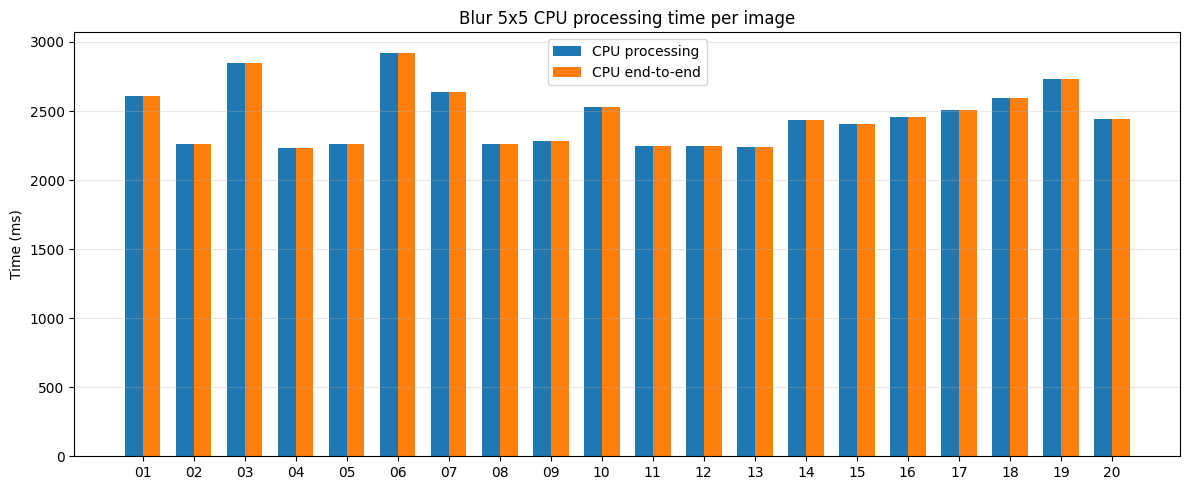


Blur 5x5 batch summary
Images processed:                 20
Total pixels processed:           8,192,000
CPU processing total time:        49148.969 ms
CPU end-to-end total time:        49148.977 ms
Batch wall time:                  49s (49.467 s)
CPU processing mean per image:    2457.448 ms
CPU end-to-end mean per image:    2457.449 ms
CPU processing throughput:        0.167 MPixels/s
CPU end-to-end throughput:        0.167 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            5.8% / 11.5%
RAM load before/after:            88.6% / 91.4%
Power before/after:               nan W / nan W
Energy, processing time:          nan J
Energy, end-to-end time:          nan J
CPU runtime load:                 11.5% snapshot
Per-image CSV:                    C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\blur5x5\blur5x5_per_image_results.csv
Summary CSV:                      C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\blur5x5\blur5x5_summary.csv
Timing

In [ ]:

# Cell 1: Blur 5x5 results on 20 images
# -------------------------------------------------

try:
    blur_batch_result = run_kernel_on_batch("blur5x5")
except Exception:
    print("Blur batch run failed.")
    traceback.print_exc()
    blur_batch_result = None


Loaded 20 images from C:\Users\Iva\Desktop\final_Files\input
First image: 01.jpg (640, 640) uint8
Last image: 20.jpg (640, 640) uint8

CPU batch run: Edge emphasis 5x5
Images: 20
Image size: 640x640
Output folder: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\edge_emphasis5x5
before_edge_emphasis5x5: CPU=2.1% | RAM=7233.7/7916.5 MB (91.4%) | Process=119.1 MB | Load1=nan | Temp=nan C | Power=nan W
  Power sensor: not available. Energy will be N/A unless MANUAL_POWER_WATTS is set.

Measured batch processing


C:\Users\Iva\AppData\Local\Temp\ipykernel_8896\204186114.py:48: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(arr.astype(np.uint8), mode="L").save(path)


  01/20 01.jpg: processing=2653.224 ms, total=2653.224 ms, out min/max/mean=0/255/252.23
  02/20 02.jpg: processing=2640.850 ms, total=2640.850 ms, out min/max/mean=0/255/254.20
  03/20 03.jpg: processing=2626.243 ms, total=2626.244 ms, out min/max/mean=0/255/251.03
  04/20 04.jpg: processing=2597.211 ms, total=2597.212 ms, out min/max/mean=0/255/252.86
  05/20 05.jpg: processing=2562.431 ms, total=2562.431 ms, out min/max/mean=0/255/253.75
  06/20 06.jpg: processing=2558.594 ms, total=2558.594 ms, out min/max/mean=0/255/253.37
  07/20 07.jpg: processing=2689.743 ms, total=2689.743 ms, out min/max/mean=0/255/253.91
  08/20 08.jpg: processing=2560.527 ms, total=2560.528 ms, out min/max/mean=0/255/240.96
  09/20 09.jpg: processing=2763.610 ms, total=2763.610 ms, out min/max/mean=0/255/253.95
  10/20 10.jpg: processing=2580.296 ms, total=2580.297 ms, out min/max/mean=0/255/253.53
  11/20 11.jpg: processing=2563.196 ms, total=2563.196 ms, out min/max/mean=0/255/253.60
  12/20 12.jpg: proce

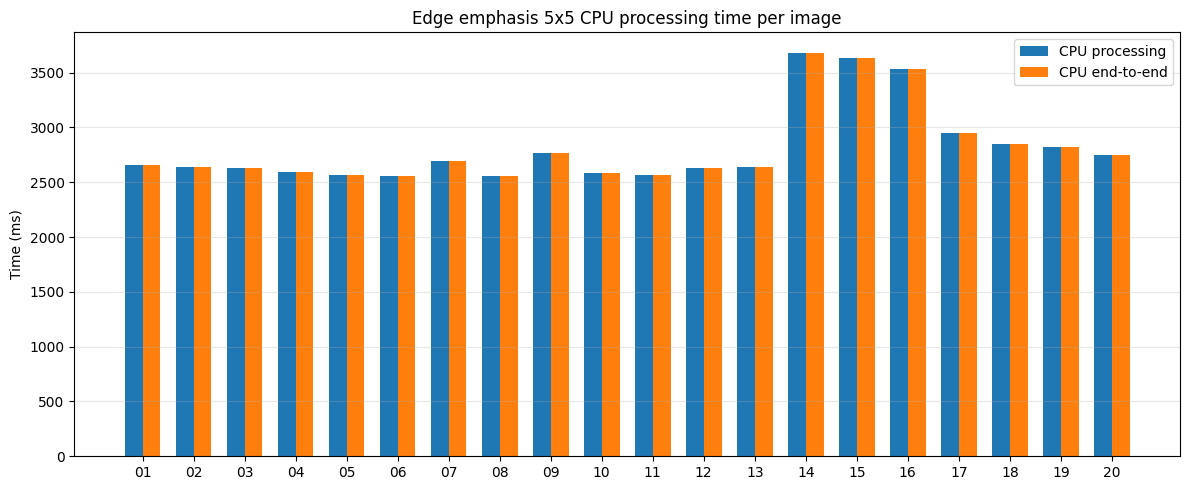


Edge emphasis 5x5 batch summary
Images processed:                 20
Total pixels processed:           8,192,000
CPU processing total time:        56274.689 ms
CPU end-to-end total time:        56274.697 ms
Batch wall time:                  56s (56.409 s)
CPU processing mean per image:    2813.734 ms
CPU end-to-end mean per image:    2813.735 ms
CPU processing throughput:        0.146 MPixels/s
CPU end-to-end throughput:        0.146 MPixels/s
Temperature before/after:         nan C / nan C
CPU load before/after:            2.1% / 10.8%
RAM load before/after:            91.4% / 83.3%
Power before/after:               nan W / nan W
Energy, processing time:          nan J
Energy, end-to-end time:          nan J
CPU runtime load:                 10.8% snapshot
Per-image CSV:                    C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\edge_emphasis5x5\edge_emphasis5x5_per_image_results.csv
Summary CSV:                      C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\edge_em

In [7]:

# =============================================================================
# Cell 2: Edge-emphasis 5x5 results on 20 images
# =============================================================================

try:
    edge_batch_result = run_kernel_on_batch("edge_emphasis5x5")
except Exception:
    print("Edge-emphasis batch run failed.")
    traceback.print_exc()
    edge_batch_result = None



Combined CPU batch statistics
Saved combined CSV: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\combined_cpu_batch_statistics.csv
Saved text summary: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\combined_cpu_batch_summary.txt

Blur 5x5
--------
Images processed:               20
Total pixels:                   8,192,000
CPU processing total time:      49148.969 ms
CPU end-to-end total time:      49148.977 ms
Batch wall time:                49.467 s
Processing throughput:          0.167 MPixels/s
End-to-end throughput:          0.167 MPixels/s
Temperature before/after:       nan C / nan C
CPU load before/after:          5.8% / 11.5%
RAM load before/after:          88.6% / 91.4%
Average power:                  nan W
Energy end-to-end:              nan J
CPU runtime load:               11.5% snapshot

Edge emphasis 5x5
-----------------
Images processed:               20
Total pixels:                   8,192,000
CPU processing total time:      56274.689 ms
CPU end-to-end total t

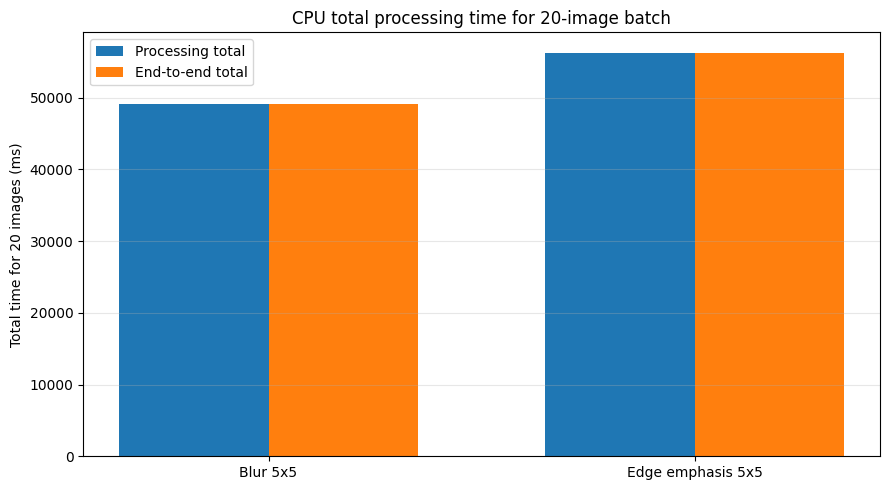

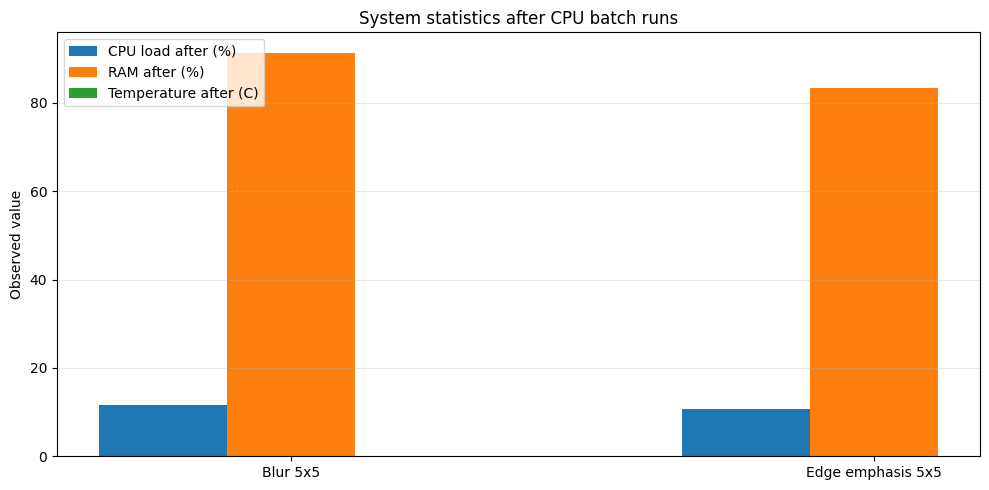

Saved timing chart: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\combined_total_timing.png
Saved system stats chart: C:\Users\Iva\Desktop\final_Files\cpu_only_outputs\combined_system_statistics.png


In [8]:

# =============================================================================
# Cell 3: Final combined statistics
# =============================================================================

def save_combined_statistics() -> None:
    folder = notebook_folder()
    out_dir = folder / OUTPUT_DIR
    out_dir.mkdir(parents=True, exist_ok=True)

    results = [r for r in ALL_BATCH_RESULTS.values() if r is not None]
    if not results:
        print("No batch results found. Run the blur and edge-emphasis cells first.")
        return

    summary_rows = []
    for r in results:
        row = {k: v for k, v in r.items() if k != "per_image"}
        summary_rows.append(row)

    combined_csv = out_dir / "combined_cpu_batch_statistics.csv"
    with combined_csv.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)

    # Text summary for report/presentation.
    summary_txt = out_dir / "combined_cpu_batch_summary.txt"
    with summary_txt.open("w", encoding="utf-8") as f:
        f.write("CPU-only Conv2D batch performance summary\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Input set: {EXPECTED_IMAGE_COUNT} images from ./{INPUT_DIR_NAME}/\n")
        f.write(f"Image size: {EXPECTED_IMAGE_SIZE[0]}x{EXPECTED_IMAGE_SIZE[1]}\n")
        f.write(f"Platform: {platform.platform()}\n\n")

        for r in results:
            f.write(f"{r['kernel_display']}\n")
            f.write("-" * 40 + "\n")
            f.write(f"Images processed: {r['image_count']}\n")
            f.write(f"Total pixels: {r['total_pixels']:,}\n")
            f.write(f"CPU processing total time: {r['cpu_processing_total_ms']:.3f} ms\n")
            f.write(f"CPU end-to-end total time: {r['cpu_end_to_end_total_ms']:.3f} ms\n")
            f.write(f"Wall time: {r['batch_wall_time_s']:.3f} s\n")
            f.write(f"Processing throughput: {r['cpu_processing_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"End-to-end throughput: {r['cpu_end_to_end_throughput_mpix_s']:.3f} MPixels/s\n")
            f.write(f"Temperature before/after: {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C\n")
            f.write(f"CPU load before/after: {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%\n")
            f.write(f"RAM load before/after: {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%\n")
            f.write(f"Average power: {r['average_power_w']:.6f} W\n")
            f.write(f"Energy end-to-end: {r['energy_end_to_end_j']:.6f} J\n")
            f.write(f"CPU runtime load note: {r['cpu_runtime_load_note']}\n")
            f.write(f"Power note: {r['power_note']}\n\n")

    print("\n" + "=" * 100)
    print("Combined CPU batch statistics")
    print("=" * 100)
    print(f"Saved combined CSV: {combined_csv}")
    print(f"Saved text summary: {summary_txt}")

    for r in results:
        print("\n" + r["kernel_display"])
        print("-" * len(r["kernel_display"]))
        print(f"Images processed:               {r['image_count']}")
        print(f"Total pixels:                   {r['total_pixels']:,}")
        print(f"CPU processing total time:      {r['cpu_processing_total_ms']:.3f} ms")
        print(f"CPU end-to-end total time:      {r['cpu_end_to_end_total_ms']:.3f} ms")
        print(f"Batch wall time:                {r['batch_wall_time_s']:.3f} s")
        print(f"Processing throughput:          {r['cpu_processing_throughput_mpix_s']:.3f} MPixels/s")
        print(f"End-to-end throughput:          {r['cpu_end_to_end_throughput_mpix_s']:.3f} MPixels/s")
        print(f"Temperature before/after:       {r['temperature_before_c']:.1f} C / {r['temperature_after_c']:.1f} C")
        print(f"CPU load before/after:          {r['cpu_load_before_percent']:.1f}% / {r['cpu_load_after_percent']:.1f}%")
        print(f"RAM load before/after:          {r['ram_percent_before']:.1f}% / {r['ram_percent_after']:.1f}%")
        print(f"Average power:                  {r['average_power_w']:.6f} W")
        print(f"Energy end-to-end:              {r['energy_end_to_end_j']:.6f} J")
        print(f"CPU runtime load:               {r['cpu_runtime_load_percent']:.1f}% snapshot")

    # Combined timing chart.
    labels = [r["kernel_display"] for r in results]
    x = np.arange(len(results), dtype=np.float64)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, [r["cpu_processing_total_ms"] for r in results], width, label="Processing total")
    plt.bar(x + width / 2, [r["cpu_end_to_end_total_ms"] for r in results], width, label="End-to-end total")
    plt.xticks(x, labels)
    plt.ylabel("Total time for 20 images (ms)")
    plt.title("CPU total processing time for 20-image batch")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    chart_path = out_dir / "combined_total_timing.png"
    plt.savefig(chart_path, dpi=180)
    plt.show()

    # System statistics chart.
    plt.figure(figsize=(10, 5))
    x = np.arange(len(results), dtype=np.float64)
    width = 0.22
    plt.bar(x - width, [r["cpu_load_after_percent"] for r in results], width, label="CPU load after (%)")
    plt.bar(x, [r["ram_percent_after"] for r in results], width, label="RAM after (%)")
    plt.bar(x + width, [r["temperature_after_c"] for r in results], width, label="Temperature after (C)")
    plt.xticks(x, labels)
    plt.ylabel("Observed value")
    plt.title("System statistics after CPU batch runs")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    stats_chart_path = out_dir / "combined_system_statistics.png"
    plt.savefig(stats_chart_path, dpi=180)
    plt.show()

    print(f"Saved timing chart: {chart_path}")
    print(f"Saved system stats chart: {stats_chart_path}")


save_combined_statistics()
